  subject_id  trial_id                ProlificID  Trial_ID2    probe      rt  \
0     sub-01         0  5cd9dd09c8e37500018ab627          1   FOREST  1618.0   
1     sub-01         1  5cd9dd09c8e37500018ab627          2   SINGLE  1769.0   
2     sub-01         2  5cd9dd09c8e37500018ab627          3     CITY  1223.0   
3     sub-01         3  5cd9dd09c8e37500018ab627          4  RESPITE  2691.0   
4     sub-01         4  5cd9dd09c8e37500018ab627          5     NEAR  1911.0   

   rt_true  sus  bin_acc  response  ... I_Mean_RT     I_SD  I_Mean_Accuracy  \
0   1618.0    0        1       2.0  ...   699.333  384.178             0.97   
1   1769.0    0        1       3.0  ...   661.688  473.849             0.97   
2   1223.0    0        1       1.0  ...   578.516  166.718             0.97   
3      NaN    0        0       3.0  ...   731.391  206.945             0.70   
4   1911.0    0        1       1.0  ...   582.121  155.744             1.00   

    age     sex               prolific_id   

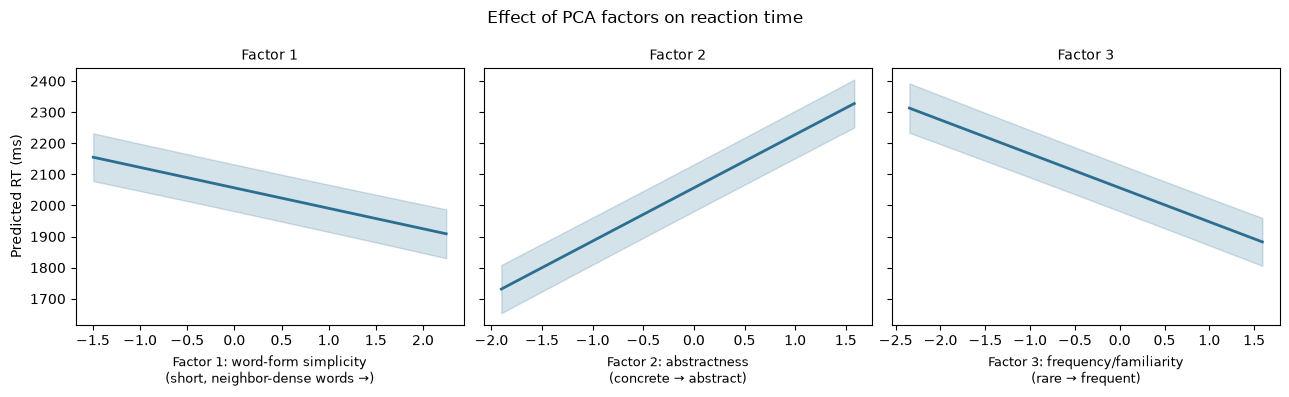

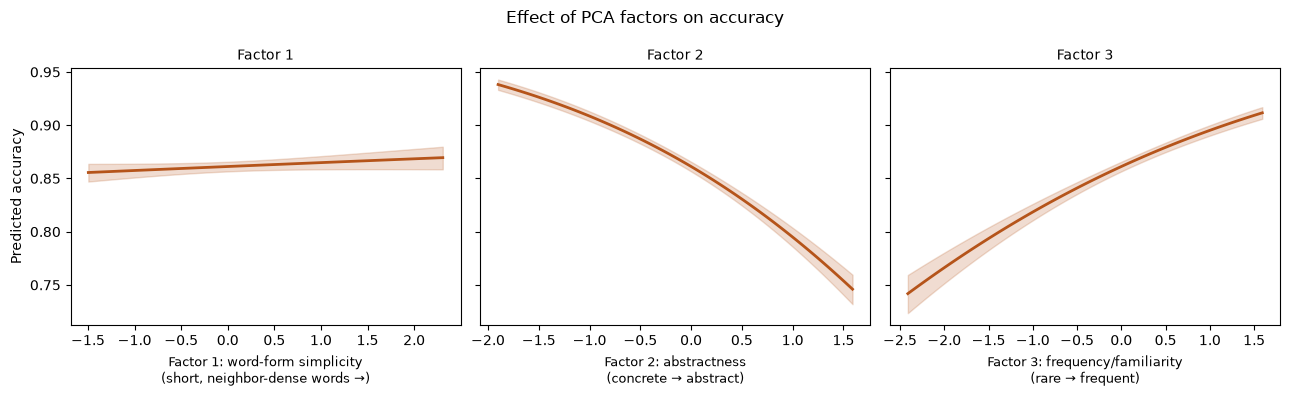


Saved rt_effects.png and accuracy_effects.png to /group/mlr-lab/GB/norming2024/SJT/derivatives/results/


In [ ]:
"""
SJT pipeline:
1. Load trial-level data.
2. Run varimax PCA (via FactorAnalyzer) on the 9 lexical predictors at the
   ITEM level (one row per unique word) rather than the trial level.
3. Merge the resulting factor scores back onto every trial via the `probe`
   (word) column.
4. Fit a linear mixed model for RT and a mixed logistic model for accuracy.

"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import mixedlm
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import matplotlib
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Optional shim: factor_analyzer calls check_array(force_all_finite=...),
# which scikit-learn renamed to ensure_all_finite in 1.6 (and removed the old
# name entirely in 1.8). Depending on which scikit-learn is installed, EITHER
# name may be the wrong one to pass. Inspect the real signature at runtime
# instead of guessing, so this works regardless of sklearn version.
# ---------------------------------------------------------------------------

import inspect
import sklearn.utils
import factor_analyzer.factor_analyzer as fa_mod

_orig_check_array = sklearn.utils.check_array
_accepted_params = set(inspect.signature(_orig_check_array).parameters)


def _patched_check_array(*args, **kwargs):
    if "force_all_finite" in kwargs and "force_all_finite" not in _accepted_params:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    elif "ensure_all_finite" in kwargs and "ensure_all_finite" not in _accepted_params:
        kwargs["force_all_finite"] = kwargs.pop("ensure_all_finite")
    return _orig_check_array(*args, **kwargs)

fa_mod.check_array = _patched_check_array

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
FILE_PATH = ""      # change to wherever you have the SJT trial-level subject data (must export to csv if in .xlsx format)
data = pd.read_csv(FILE_PATH)
print(data.head())

predictor_cols = [
    "Length",
    "LgSUBTLWF",
    "Ortho_N",
    "Phono_N",
    "Concreteness_Rating",
    "Semantic_Neighborhood_Density",
    "Semantic_Diversity",
    "Age_Of_Acquisition",
    "NSyll",
]

# ---------------------------------------------------------------------------
# STEP 1: varimax PCA at the ITEM level
# ---------------------------------------------------------------------------
# Predictors are properties of the word (probe), not the trial - every trial
# using the same word has identical predictor values. Fitting the PCA on all
# trial rows just replays each word's row ~49 times. The correct unit of
# analysis is one row per unique word.

item_data = data.drop_duplicates(subset="probe")[["probe"] + predictor_cols].dropna()
print(f"\n{len(item_data)} unique items entering the PCA "
      f"(of {data['probe'].nunique()} unique probes total)")

scaler = StandardScaler()
X_items = scaler.fit_transform(item_data[predictor_cols])

n_factors = 3
fa = FactorAnalyzer(rotation="varimax", n_factors=n_factors, method="principal")
fa.fit(X_items)

loadings = pd.DataFrame(
    fa.loadings_,
    index=predictor_cols,
    columns=[f"Factor_{i + 1}" for i in range(n_factors)],
)
print("\nFactor Loadings:\n", loadings)

eigenvalues, _ = fa.get_eigenvalues()
print("\nEigenvalues:", eigenvalues)
print("Cumulative variance explained (eigenvalues/sum):",
      np.cumsum(eigenvalues) / np.sum(eigenvalues))

# Factor scores for each unique item using the model's own scoring
# coefficients (fa.transform), not a manual dot-product with the loadings -
# transform() applies regression-based scoring weights, which are not the
# same thing as the loadings themselves.

item_scores = pd.DataFrame(
    fa.transform(X_items),
    columns=[f"Factor_{i + 1}" for i in range(n_factors)],
)
item_scores["probe"] = item_data["probe"].values

# ---------------------------------------------------------------------------
# STEP 2: merge item-level factor scores onto every trial
# ---------------------------------------------------------------------------
df_pca = data.merge(item_scores, on="probe", how="left")
df_pca["subject_id"] = df_pca["subject_id"].astype(str)
df_pca["acc"] = df_pca["bin_acc"]
df_pca["rt"] = df_pca["rt_true"]

factor_cols = [f"Factor_{i + 1}" for i in range(n_factors)]

df_rt = df_pca.dropna(subset=["rt", *factor_cols, "subject_id"]).reset_index(drop=True)
df_acc = df_pca.dropna(subset=["acc", *factor_cols, "subject_id"]).reset_index(drop=True)

print(f"\nRT model N = {len(df_rt)} trials, {df_rt['subject_id'].nunique()} subjects")
print(f"Accuracy model N = {len(df_acc)} trials, {df_acc['subject_id'].nunique()} subjects")

# ---------------------------------------------------------------------------
# STEP 3: linear mixed model for RT
# ---------------------------------------------------------------------------
model_rt = mixedlm("rt ~ Factor_1 + Factor_2 + Factor_3", df_rt, groups=df_rt["subject_id"])
result_rt = model_rt.fit()
print("\nREACTION TIME MODEL SUMMARY:")
print(result_rt.summary())

# ---------------------------------------------------------------------------
# STEP 4: mixed logistic model for accuracy
# ---------------------------------------------------------------------------
df_acc["acc"] = df_acc["acc"].astype(int)
model_acc = BinomialBayesMixedGLM.from_formula(
    "acc ~ Factor_1 + Factor_2 + Factor_3",
    {"subject": "0 + C(subject_id)"},
    df_acc,
)
result_acc = model_acc.fit_vb()
print("\nACCURACY MODEL SUMMARY:")
print(result_acc.summary())

# ---------------------------------------------------------------------------
# STEP 5: effect-size plots
# ---------------------------------------------------------------------------
# Predicted RT / accuracy across the observed range of each factor, holding
# the other two factors at 0 (their mean, since they come from a PCA on
# standardized predictors). 95% CIs from the fixed-effect covariance
# (delta method); random-effect/subject variance is not included, so these
# are population-average (not subject-specific) predictions.

OUT_DIR = ""  # change to wherever you want the figures saved
 
factor_labels = {
    "Factor_1": "Factor 1: word-form simplicity\n(short, neighbor-dense words \u2192)",
    "Factor_2": "Factor 2: abstractness\n(concrete \u2192 abstract)",
    "Factor_3": "Factor 3: frequency/familiarity\n(rare \u2192 frequent)",
}
 
# --- RT effects ---
fe = result_rt.fe_params
cov = result_rt.cov_params().loc[
    ["Intercept", *factor_cols], ["Intercept", *factor_cols]
].values
 
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, fcol in zip(axes, factor_cols):
    xr = np.linspace(df_rt[fcol].quantile(0.02), df_rt[fcol].quantile(0.98), 100)
    preds, ses = [], []
    for x in xr:
        xv = np.zeros(4)
        xv[0] = 1.0
        xv[factor_cols.index(fcol) + 1] = x
        preds.append(xv @ fe.values)
        ses.append(np.sqrt(xv @ cov @ xv))
    preds, ses = np.array(preds), np.array(ses)
    ax.plot(xr, preds, color="#2c6e91", lw=2)
    ax.fill_between(xr, preds - 1.96 * ses, preds + 1.96 * ses, color="#2c6e91", alpha=0.2)
    ax.set_xlabel(factor_labels[fcol], fontsize=9)
    ax.set_title(fcol.replace("_", " "), fontsize=10)
axes[0].set_ylabel("Predicted RT (ms)")
fig.suptitle("Effect of PCA factors on reaction time", fontsize=12)
fig.tight_layout()
plt.show()
fig.savefig(f"{OUT_DIR}/rt_effects.png", dpi=200)
plt.close(fig)
 
# --- Accuracy effects ---
fe_a = result_acc.fe_mean
sd_a = result_acc.fe_sd
 
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, fcol in zip(axes, factor_cols):
    xr = np.linspace(df_acc[fcol].quantile(0.02), df_acc[fcol].quantile(0.98), 100)
    logit_preds, logit_ses = [], []
    for x in xr:
        xv = np.zeros(4)
        xv[0] = 1.0
        xv[factor_cols.index(fcol) + 1] = x
        logit_preds.append(xv @ fe_a)
        logit_ses.append(np.sqrt(np.sum((xv ** 2) * (sd_a ** 2))))
    logit_preds, logit_ses = np.array(logit_preds), np.array(logit_ses)
    prob = 1 / (1 + np.exp(-logit_preds))
    lo = 1 / (1 + np.exp(-(logit_preds - 1.96 * logit_ses)))
    hi = 1 / (1 + np.exp(-(logit_preds + 1.96 * logit_ses)))
    ax.plot(xr, prob, color="#b5541a", lw=2)
    ax.fill_between(xr, lo, hi, color="#b5541a", alpha=0.2)
    ax.set_xlabel(factor_labels[fcol], fontsize=9)
    ax.set_title(fcol.replace("_", " "), fontsize=10)
axes[0].set_ylabel("Predicted accuracy")
fig.suptitle("Effect of PCA factors on accuracy", fontsize=12)
fig.tight_layout()
plt.show()
fig.savefig(f"{OUT_DIR}/accuracy_effects.png", dpi=200)
plt.close(fig)
 
print(f"\nSaved rt_effects.png and accuracy_effects.png to {OUT_DIR}")

The three factors have clear psycholinguistic identities:

Factor 1 — Word form / neighborhood density. Loads negatively on Length (-0.85) and NSyll (-0.79), positively on Ortho_N (0.89) and Phono_N (0.89). High scores = short words with many orthographic/phonological neighbors. This is essentially a "wordform simplicity" dimension.
Factor 2 — Abstractness. Dominated by Concreteness (-0.89) and Semantic Diversity (0.76), with a moderate AoA loading (0.34). High scores = abstract words used across many different contexts, acquired later.
Factor 3 — Frequency / familiarity. Driven by LgSUBTLWF (0.86) and Semantic Neighborhood Density (0.85), with a strong negative AoA loading (-0.68). High scores = frequent, semantically well-connected words learned early.

Together they explain about 80% of the variance in the 9 predictors, which is a solid reduction from 9 variables to 3 interpretable dimensions.
RT model — all three factors are significant, and the direction of each effect matches what you'd expect from the literature:

Factor  Effect on RT    Interpretation

Factor 1 (form simplicity)  -66 ms  Shorter, neighbor-dense words → faster responses

Factor 2 (abstractness)     +171 ms Abstract, semantically diverse words → slower responses

Factor 3 (frequency)        -109 ms Frequent, familiar words → faster responses

The abstractness effect is the largest of the three — abstractness is costing people almost 3x as much time as the form-simplicity effect.

Accuracy model — this one uses Bayesian posterior means/SDs rather than p-values, so "significance" here means the interval (mean ± ~2 SD) excludes zero:

Factor 1: 0.031 ± 0.038 → crosses zero, not a credible effect. Word form doesn't meaningfully predict accuracy.
Factor 2: -0.471 ± 0.040 → credible, negative. More abstract words → lower accuracy.
Factor 3: 0.319 ± 0.036 → credible, positive. More frequent/familiar words → higher accuracy.

So the pattern across both DVs is consistent: abstractness hurts both speed and accuracy, frequency helps both, and word-form simplicity only affects speed, not accuracy. That's a fairly clean, theoretically sensible dissociation — form-level properties affect processing speed but not the correctness of the semantic judgment, while frequency and abstractness affect both.